In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [3]:
# Global Style Settings
sns.set_theme(style='darkgrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.family'] = 'DejaVu Sans'

In [4]:
# Color palette used throughout the project
COLORS = sns.color_palette('viridis', 10)
HIGHLIGHT = '#e74c3c'
PRIMARY   = '#2ecc71'

df = pd.read_csv('/content/IPL DataSet - Ball_by_Ball Cleaned.csv')

# Clean
df = df.dropna(how='all')
df = df.dropna(subset=['Match_Id','Innings_Id','Over_Id','Ball_Id'])


df['Batsman_Scored']  = pd.to_numeric(df['Batsman_Scored'],  errors='coerce').fillna(0).astype(int)
df['Extra_Runs']      = pd.to_numeric(df['Extra_Runs'],      errors='coerce').fillna(0).astype(int)
df['Match_Winner_Id'] = pd.to_numeric(df['Match_Winner_Id'], errors='coerce').fillna(0).astype(int)
df['Extra_Type']      = df['Extra_Type'].fillna('Normal')
df['Total_Runs']      = df['Batsman_Scored'] + df['Extra_Runs']


print("✅ Libraries imported & data cleaned!")
print(f"📊 Total Deliveries : {len(df):,}")
print(f"🏟️  Total Matches    : {df['Match_Id'].nunique():,}")
print(f"🏏  Total Batsmen    : {df['Striker_Id'].nunique():,}")
print(f"🎳  Total Bowlers    : {df['Bowler_Id'].nunique():,}")


✅ Libraries imported & data cleaned!
📊 Total Deliveries : 136,590
🏟️  Total Matches    : 577
🏏  Total Batsmen    : 434
🎳  Total Bowlers    : 331


In [5]:
# Q2. How clean is the data? (Missing values & Data Types)

print("=" * 50)
print("        🔍 DATA QUALITY REPORT")
print("=" * 50)

# Data Types
print("\n📋 Column Data Types:")
print(df.dtypes)

# Missing Values
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({
    'Missing Values' : missing,
    'Percentage (%)' : missing_pct
}).query('`Missing Values` > 0')

print("\n⚠️  Columns with Missing Values:")
print(missing_df if len(missing_df) > 0 else "✅ No missing values found!")

# Clean
df = df.dropna(how='all')
df = df.dropna(subset=['Match_Id','Innings_Id','Over_Id','Ball_Id'])
df['Batsman_Scored']  = pd.to_numeric(df['Batsman_Scored'],  errors='coerce').fillna(0).astype(int)
df['Extra_Runs']      = pd.to_numeric(df['Extra_Runs'],      errors='coerce').fillna(0).astype(int)
df['Match_Winner_Id'] = pd.to_numeric(df['Match_Winner_Id'], errors='coerce').fillna(0).astype(int)
df['Extra_Type']      = df['Extra_Type'].fillna('Normal')
df['Total_Runs']      = df['Batsman_Scored'] + df['Extra_Runs']

print("\n✅ Data Cleaned Successfully!")
print(f"📐 Final Shape : {df.shape[0]:,} rows × {df.shape[1]} columns")

        🔍 DATA QUALITY REPORT

📋 Column Data Types:
Match_Id                    float64
Innings_Id                  float64
Over_Id                     float64
Ball_Id                     float64
Team_Batting_Id             float64
Team_Bowling_Id             float64
Striker_Id                  float64
Striker_Batting_Position    float64
Non_Striker_Id              float64
Bowler_Id                   float64
Batsman_Scored                int64
Extra_Type                   object
Extra_Runs                    int64
Player_dissmial_id            int64
Dissimal_Type                object
Fielder_id                    int64
Match_Winner_Id               int64
Strike_Rate                 float64
Total_Runs                    int64
dtype: object

⚠️  Columns with Missing Values:
             Missing Values  Percentage (%)
Strike_Rate          136590           100.0

✅ Data Cleaned Successfully!
📐 Final Shape : 136,590 rows × 19 columns


# Q3. How many runs are scored in each game phase?


In [6]:
def get_phase(over):
  if over <= 6 :
    return 'Powerplay(1-6)'
  elif over <= 15:
    return 'Middle (7-15)'
  else:
    return 'Death (16-20)'

df['Phase'] = df['Over_Id'].apply(get_phase)
phase_order = ['Powerplay (1-6) , Middle(7-15) , Death(16-20)']


phase_runs = df.groupby('Phase')['Total_Runs'].sum().reindex(phase_order)



Phase
Powerplay (1-6)    48011
Middle (7-15)      72847
Death (16-20)      45092
Name: Batsman_Scored, dtype: int64


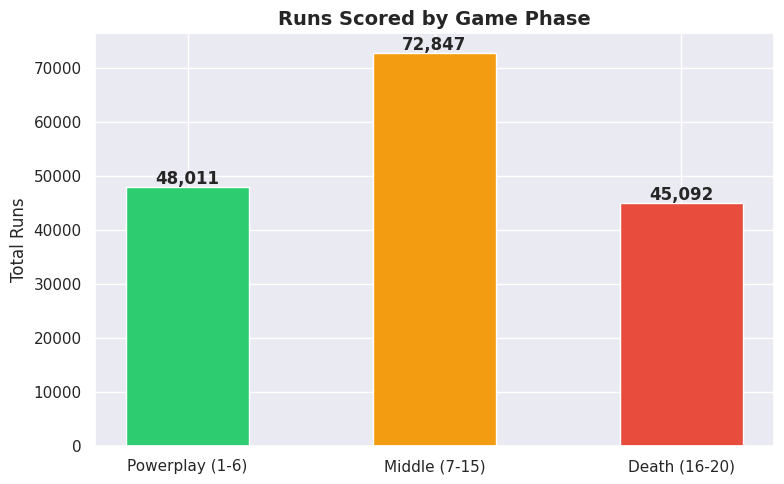

In [7]:
# Q3. How many runs are scored in each game phase?

def get_phase(over):
    if over <= 6:    return 'Powerplay (1-6)'
    elif over <= 15: return 'Middle (7-15)'
    else:            return 'Death (16-20)'

df['Phase'] = df['Over_Id'].apply(get_phase)
phase_order = ['Powerplay (1-6)', 'Middle (7-15)', 'Death (16-20)']

phase_runs = df.groupby('Phase')['Batsman_Scored'].sum().reindex(phase_order)

print(phase_runs)  # check values first

plt.figure(figsize=(8, 5))
bars = plt.bar(phase_runs.index, phase_runs.values,
               color=['#2ecc71', '#f39c12', '#e74c3c'],
               edgecolor='white', width=0.5)

plt.title('Runs Scored by Game Phase', fontsize=14, fontweight='bold')
plt.ylabel('Total Runs')

for bar in bars:
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 500,
             f'{int(bar.get_height()):,}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

# Q4. Which over is the most explosive? (Avg runs per over)


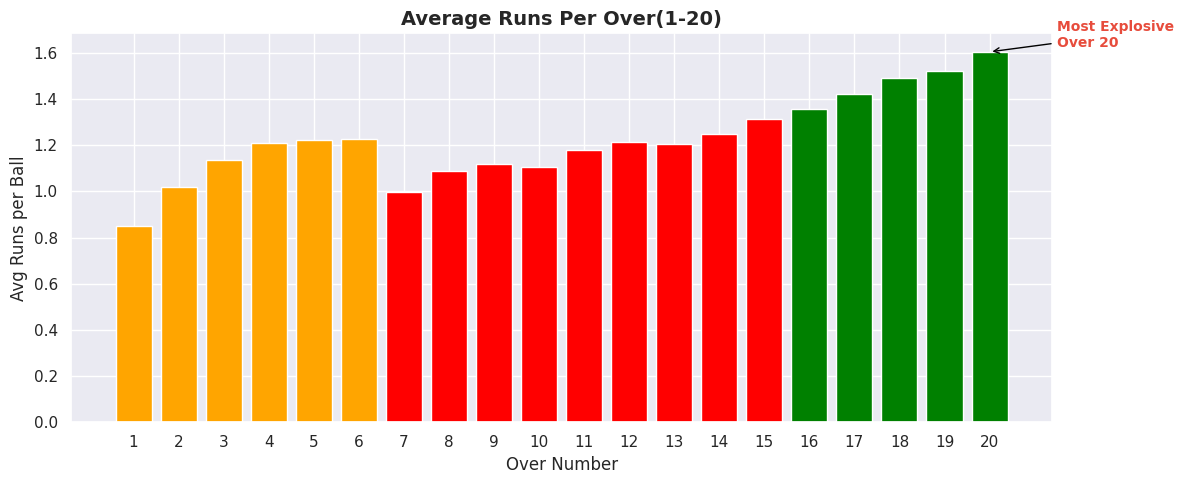

Most Explosive Over : Over 20 (1.60 avg runs/ball)


In [8]:
over_runs = df.groupby('Over_Id')['Batsman_Scored'].mean().reset_index()
over_runs.columns = ['Over' , 'Avg_Runs']

plt.figure(figsize = (12,5))
bars = plt.bar(over_runs['Over'],over_runs['Avg_Runs'],
       color =['Green' if x >= 16 else 'Red' if x >= 7 else 'Orange'
       for x in over_runs['Over']], edgecolor = 'white'        )

plt.title('Average Runs Per Over(1-20)' , fontsize = 14 , fontweight = 'bold')
plt.xlabel("Over Number")
plt.ylabel('Avg Runs per Ball')
plt.xticks(range(1 , 21))

# Highlight most explosive over
max_over = over_runs.loc[over_runs['Avg_Runs'].idxmax()]
plt.annotate(f"Most Explosive\nOver {int(max_over['Over'])}",
             xy=(max_over['Over'], max_over['Avg_Runs']),
             xytext=(max_over['Over'] + 1.5, max_over['Avg_Runs'] + 0.02),
             arrowprops=dict(arrowstyle='->', color='black'),
             fontsize=10, fontweight='bold', color='#e74c3c')

plt.tight_layout()
plt.show()

print(f"Most Explosive Over : Over {int(max_over['Over'])} ({max_over['Avg_Runs']:.2f} avg runs/ball)")




# Q5. What is the most common score off a single ball?


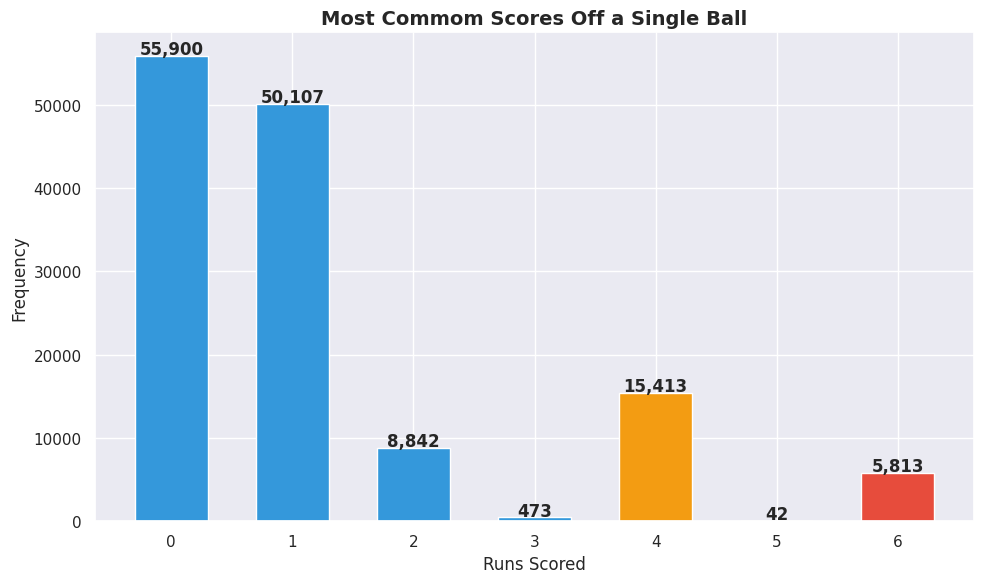

Most common score off a ball : 0 runs (55,900 times)
Total 4s hit                 : 15,413
Total 6s hit                 : 5,813
Dot ball %                   : 40.9%


In [9]:
ball_runs = df['Batsman_Scored'].value_counts().sort_index()
ball_runs = ball_runs[ball_runs.index <= 6]

plt.figure(figsize = (10 , 6))
bars = plt.bar(ball_runs.index, ball_runs.values,
               color=['#e74c3c' if x == 6 else '#f39c12' if x == 4 else '#3498db'
                      for x in ball_runs.index],
               edgecolor='white', width=0.6)

plt.title('Most Commom Scores Off a Single Ball' , fontsize = 14 , fontweight = 'bold')
plt.xlabel('Runs Scored')
plt.ylabel('Frequency')
plt.xticks(ball_runs.index)

for bar in bars:
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
             f'{int(bar.get_height()):,}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()


# Insight
most_common = ball_runs.idxmax()
print(f"Most common score off a ball : {most_common} runs ({ball_runs[most_common]:,} times)")
print(f"Total 4s hit                 : {ball_runs[4]:,}")
print(f"Total 6s hit                 : {ball_runs[6]:,}")
print(f"Dot ball %                   : {ball_runs[0] / ball_runs.sum() * 100:.1f}%")



# Q6. How does run scoring change ball-by-ball within an over?


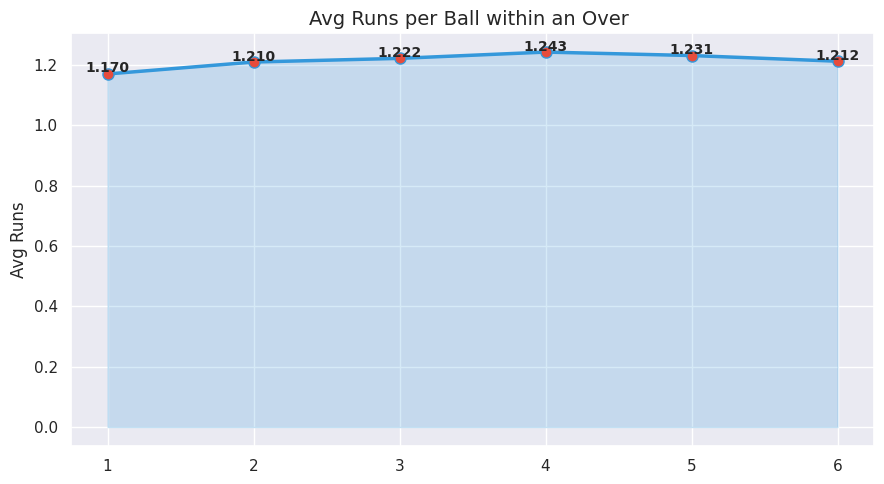

Highest scoring ball in an over : Ball 4.0 (1.243 avg runs)
Lowest scoring ball in an over  : Ball 1.0 (1.170 avg runs)


In [10]:
ball_avg = df[df['Ball_Id'] <= 6].groupby('Ball_Id')['Batsman_Scored'].mean()

plt.figure(figsize = (9,5))
plt.plot(ball_avg.index , ball_avg.values , marker = 'o' ,  color='#3498db',
         linewidth=2.5, markersize=8, markerfacecolor='#e74c3c')

plt.fill_between(ball_avg.index , ball_avg.values , alpha = 0.2 ,color='#3498db' )
plt.title('Avg Runs per Ball within an Over ' , fontsize = 14 , fontweight = 10)
plt.ylabel('Avg Runs')
plt.xticks([1, 2, 3, 4, 5, 6])

for x, y in zip(ball_avg.index, ball_avg.values):
    plt.text(x, y + 0.005, f'{y:.3f}', ha='center', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.show()

# Insight
peak_ball = ball_avg.idxmax()
print(f"Highest scoring ball in an over : Ball {peak_ball} ({ball_avg[peak_ball]:.3f} avg runs)")
print(f"Lowest scoring ball in an over  : Ball {ball_avg.idxmin()} ({ball_avg.min():.3f} avg runs)")


# Q7. Who are the Top 10 run-scorers in IPL history?


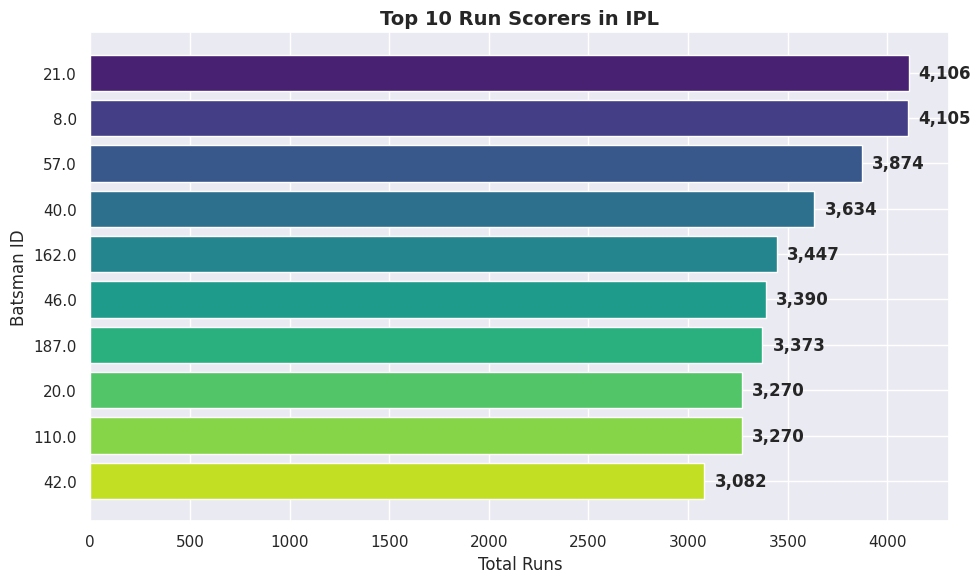

Top 5 Run Scorers:
 Striker_Id  Total_Runs  Balls_Faced  Strike_Rate  Matches
       21.0        4106         3059       134.23      143
        8.0        4105         3236       126.85      131
       57.0        3874         2996       129.31      137
       40.0        3634         3028       120.01      130
      162.0        3447         2360       146.06       91


In [11]:
# Q7. Who are the Top 10 run-scorers in IPL history?

top_batsmen = df.groupby('Striker_Id').agg(
    Total_Runs  = ('Batsman_Scored', 'sum'),
    Balls_Faced = ('Ball_Id',        'count'),
    Matches     = ('Match_Id',       'nunique')
).reset_index()

top_batsmen['Strike_Rate'] = (top_batsmen['Total_Runs'] / top_batsmen['Balls_Faced'] * 100).round(2)
top10 = top_batsmen.sort_values('Total_Runs', ascending=False).head(10)

plt.figure(figsize=(10, 6))
bars = plt.barh(top10['Striker_Id'].astype(str), top10['Total_Runs'],
                color=sns.color_palette('viridis', 10), edgecolor='white')

plt.title('Top 10 Run Scorers in IPL', fontsize=14, fontweight='bold')
plt.xlabel('Total Runs')
plt.ylabel('Batsman ID')
plt.gca().invert_yaxis()

for bar in bars:
    plt.text(bar.get_width() + 50, bar.get_y() + bar.get_height()/2,
             f'{int(bar.get_width()):,}', va='center', fontweight='bold')

plt.tight_layout()
plt.show()

# Insight
print("Top 5 Run Scorers:")
print(top10[['Striker_Id','Total_Runs','Balls_Faced','Strike_Rate','Matches']].head(5).to_string(index=False))

# Q8. Who has the best Strike Rate? (min 200 balls faced)


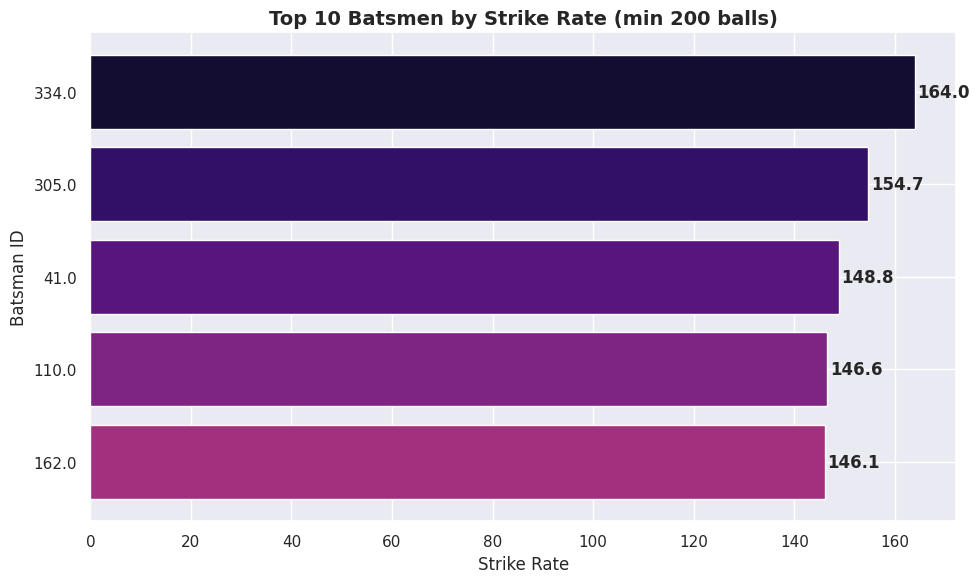

 Striker_Id  Total_Runs  Balls_Faced  Strike_Rate
      334.0         574          350       164.00
      305.0         919          594       154.71
       41.0        2728         1833       148.83
      110.0        3270         2231       146.57
      162.0        3447         2360       146.06


In [12]:
sr = df.groupby('Striker_Id').agg(
    Total_Runs = ('Batsman_Scored' , 'sum'),
    Balls_Faced = ('Ball_Id' , 'count')
).reset_index()

sr['Strike_Rate'] = (sr['Total_Runs'] / sr['Balls_Faced'] * 100).round(2)
sr = sr[sr['Balls_Faced'] >= 200].sort_values('Strike_Rate', ascending=False).head(5)

plt.figure(figsize =(10,6) )
bars = plt.barh(sr['Striker_Id'].astype(str) , sr['Strike_Rate'],
                color = sns.color_palette('magma' , 10 ) , edgecolor = 'white')


plt.title('Top 10 Batsmen by Strike Rate (min 200 balls)', fontsize=14, fontweight='bold')
plt.xlabel('Strike Rate')
plt.ylabel('Batsman ID')
plt.gca().invert_yaxis()
for bar in bars:
    plt.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
             f'{bar.get_width():.1f}', va='center', fontweight='bold')
plt.tight_layout()
plt.show()

print(sr[['Striker_Id','Total_Runs','Balls_Faced','Strike_Rate']].to_string(index=False))





# Q9. Which batting position scores the most runs?


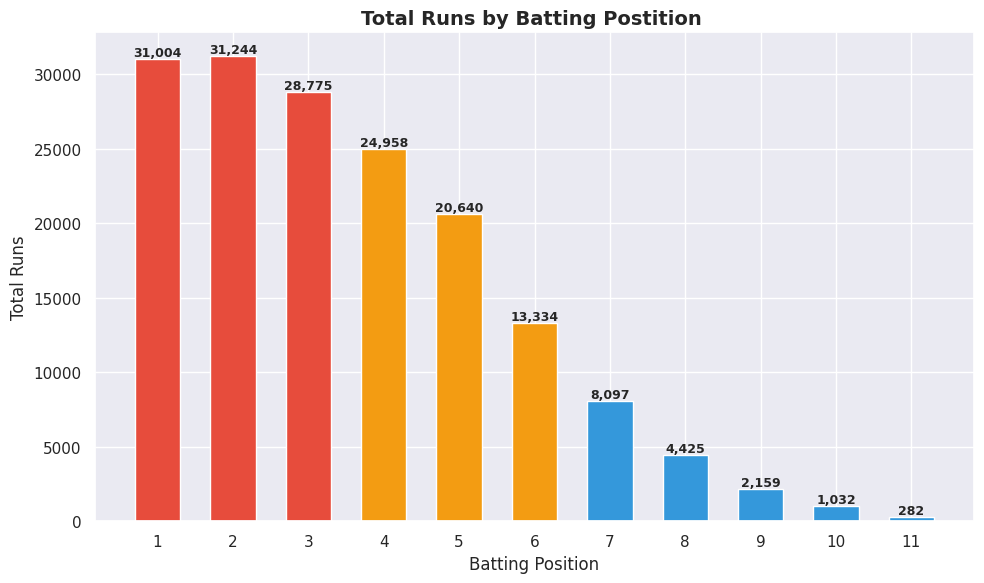

Highest scoring position : 2


In [13]:
pos = df.groupby('Striker_Batting_Position')['Batsman_Scored'].sum().reset_index()
pos.columns = ['Position' , 'Total_Runs']
pos = pos[pos['Position'] <= 11 ].sort_values('Position')

plt.figure(figsize = (10,6))

bars = plt.bar(pos['Position'], pos['Total_Runs'] , color=['#e74c3c' if x <= 3 else '#f39c12' if x <= 6 else '#3498db'
                      for x in pos['Position']],
               edgecolor='white', width=0.6
               )

plt.title('Total Runs by Batting Postition ' , fontsize = 14 , fontweight = 'bold')
plt.xlabel('Batting Position')
plt.ylabel('Total Runs')
plt.xticks(range(1, 12))
for bar in bars:
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
             f'{int(bar.get_height()):,}', ha='center', fontweight='bold', fontsize=9)
plt.tight_layout()
plt.show()

print(f"Highest scoring position : {int(pos.loc[pos['Total_Runs'].idxmax(), 'Position'])}")


# Q10. Who are the best finishers? (Avg runs in overs 16-20)


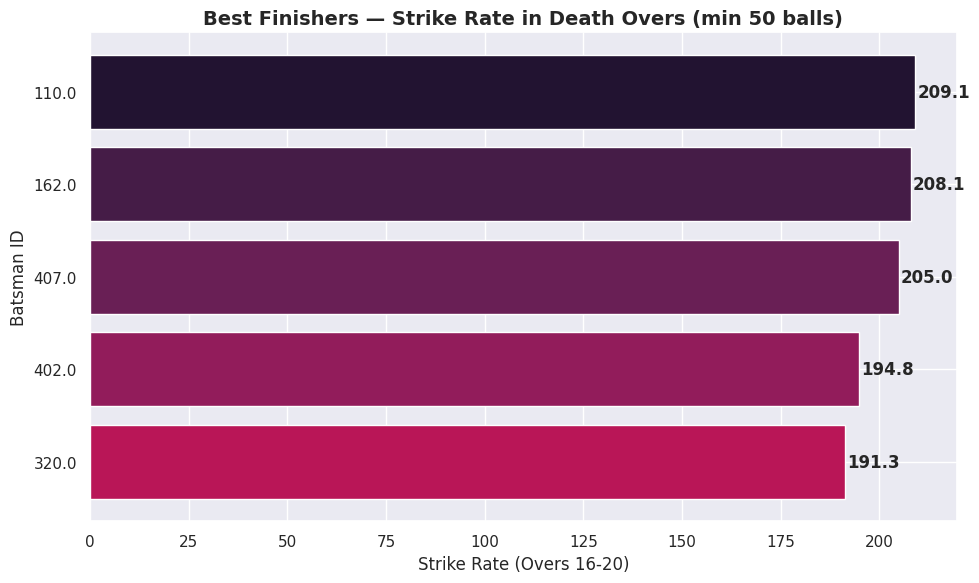

 Striker_Id  Runs  Balls  SR_Death
      110.0  1144    547    209.14
      162.0   412    198    208.08
      407.0   123     60    205.00
      402.0   150     77    194.81
      320.0   639    334    191.32


In [14]:
death = df[df['Over_Id'] >= 16 ].groupby('Striker_Id').agg(
    Runs = ('Batsman_Scored' , 'sum'),
    Balls = ('Ball_Id' , 'count')
).reset_index()

death['SR_Death'] = (death['Runs']/ death['Balls'] * 100 ).round(2)
death = death[death['Balls']>= 50].sort_values('SR_Death' , ascending = False).head(5)

plt.figure(figsize = (10,6))
bars = plt.barh(death['Striker_Id'].astype(str) , death['SR_Death'],
                color=sns.color_palette('rocket' , 10), edgecolor = 'white')

plt.title('Best Finishers — Strike Rate in Death Overs (min 50 balls)', fontsize=14, fontweight='bold')
plt.xlabel('Strike Rate (Overs 16-20)')
plt.ylabel('Batsman ID')
plt.gca().invert_yaxis()
for bar in bars:
    plt.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
             f'{bar.get_width():.1f}', va='center', fontweight='bold')
plt.tight_layout()
plt.show()

print(death[['Striker_Id','Runs','Balls','SR_Death']].to_string(index=False))

# Q11. Who are the Top 10 wicket-takers in IPL history?


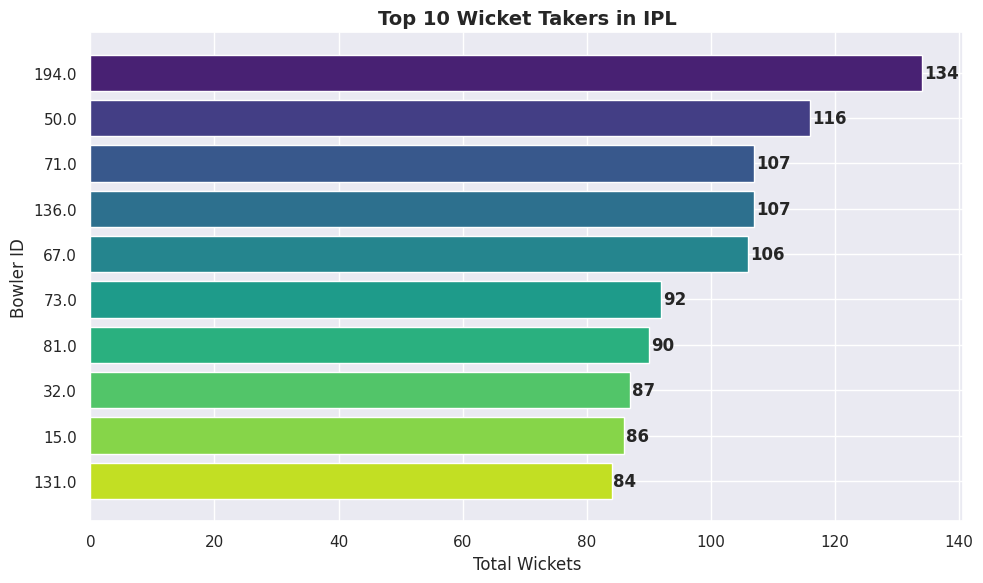

 Bowler_Id  Wickets
     194.0      134
      50.0      116
      71.0      107
     136.0      107
      67.0      106
      73.0       92
      81.0       90
      32.0       87
      15.0       86
     131.0       84


In [15]:
wickets = df[df['Player_dissmial_id'] != 0]
wickets = wickets[wickets['Dissimal_Type'] != 'run out']
top_bowlers = wickets.groupby('Bowler_Id')['Player_dissmial_id'].count().reset_index()
top_bowlers.columns = ['Bowler_Id' , 'Wickets']
top_bowlers = top_bowlers.sort_values('Wickets' , ascending = False).head(10)

plt.figure(figsize = (10,6))
bars = plt.barh(top_bowlers['Bowler_Id'].astype(str), top_bowlers['Wickets'],
                color=sns.color_palette('viridis',10), edgecolor = 'White')

plt.title('Top 10 Wicket Takers in IPL', fontsize=14, fontweight='bold')
plt.xlabel('Total Wickets')
plt.ylabel('Bowler ID')
plt.gca().invert_yaxis()
for bar in bars:
    plt.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
             f'{int(bar.get_width())}', va='center', fontweight='bold')
plt.tight_layout()
plt.show()

print(top_bowlers.to_string(index=False))

# Q12. Who are the most economical bowlers? (min 300 balls)


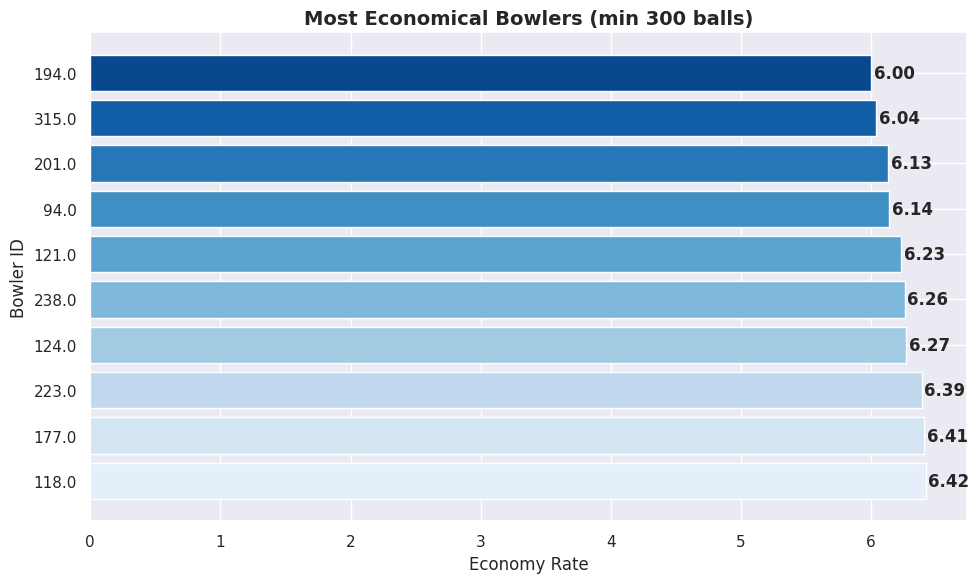

 Bowler_Id  Runs  Balls  Economy
     194.0  2407   2407     6.00
     315.0  1605   1594     6.04
     201.0  2409   2359     6.13
      94.0  2209   2159     6.14
     121.0  1642   1581     6.23
     238.0   557    534     6.26
     124.0  1027    983     6.27
     223.0   734    689     6.39
     177.0   486    455     6.41
     118.0   352    329     6.42


In [16]:
eco = df.groupby('Bowler_Id').agg(
    Runs = ('Batsman_Scored' , 'sum'),
    Balls = ('Ball_Id' , 'count')
).reset_index()

eco['Economy'] = (eco['Runs'] / eco['Balls'] * 6 ).round(2)
eco = eco[eco['Balls'] >= 300 ].sort_values('Economy').head(10)


plt.figure(figsize = (10,6))
bars = plt.barh(eco['Bowler_Id'].astype(str) , eco['Economy'],
                color=sns.color_palette('Blues_r',10), edgecolor = 'white')

plt.title('Most Economical Bowlers (min 300 balls)', fontsize=14, fontweight='bold')
plt.xlabel('Economy Rate')
plt.ylabel('Bowler ID')
plt.gca().invert_yaxis()
for bar in bars:
    plt.text(bar.get_width() + 0.02, bar.get_y() + bar.get_height()/2,
             f'{bar.get_width():.2f}', va='center', fontweight='bold')
plt.tight_layout()
plt.show()

print(eco[['Bowler_Id','Runs','Balls','Economy']].to_string(index=False))

# Q13. Which over do bowlers take the most wickets?


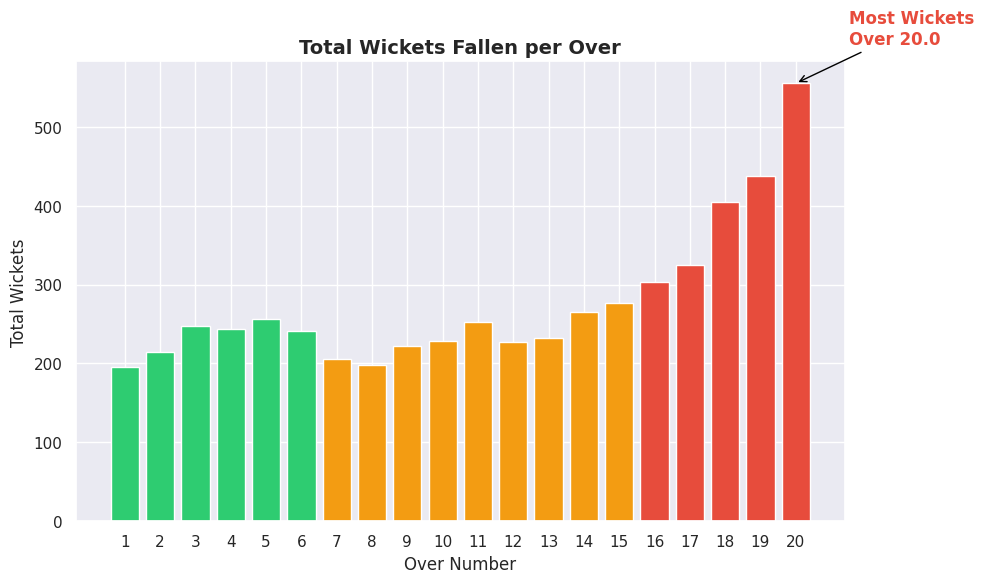

Most wickets fall in : Over 20.0 (555 wickets)


In [17]:
over_wickets = df[df['Player_dissmial_id'] != 0].groupby('Over_Id')['Player_dissmial_id'].count()

plt.figure(figsize = (10,6))
bars = plt.bar(over_wickets.index , over_wickets.values ,
               color=['#e74c3c' if x >= 16 else '#f39c12' if x >= 7 else '#2ecc71'
                      for x in over_wickets.index],
               edgecolor='white')

plt.title('Total Wickets Fallen per Over', fontsize=14, fontweight='bold')
plt.xlabel('Over Number')
plt.ylabel('Total Wickets')
plt.xticks(range(1, 21))

peak = over_wickets.idxmax()
plt.annotate(f'Most Wickets\nOver {peak}',
             xy=(peak, over_wickets[peak]),
             xytext=(peak + 1.5, over_wickets[peak] + 50),
             arrowprops=dict(arrowstyle='->', color='black'),
             fontweight='bold', color='#e74c3c')

plt.tight_layout()
plt.show()

print(f"Most wickets fall in : Over {peak} ({over_wickets[peak]} wickets)")

# Q14. Who are the most dangerous death over bowlers? (overs 16-20)


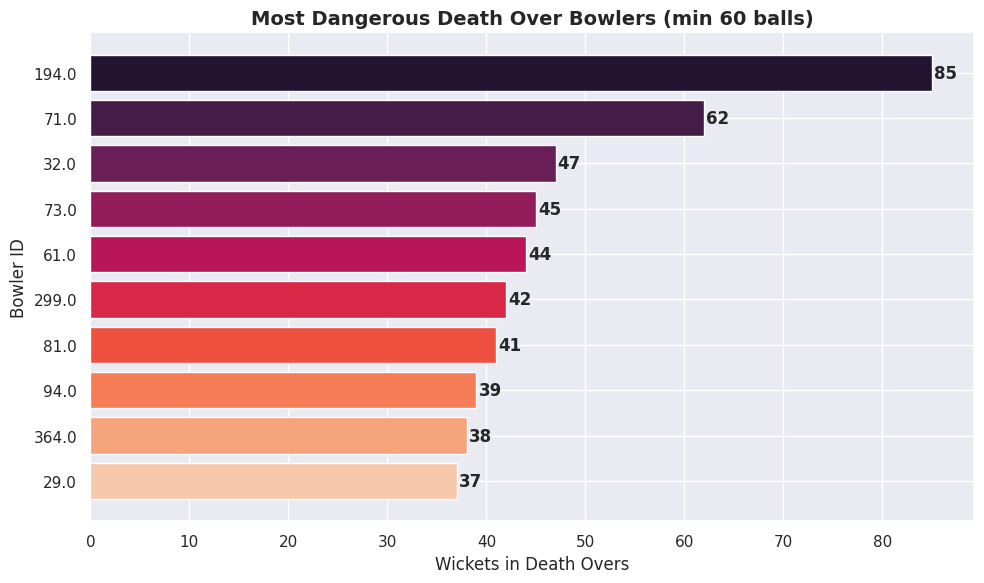

 Bowler_Id  Wickets  Balls  Economy
     194.0       85    974     6.55
      71.0       62    885     8.29
      32.0       47    555     8.29
      73.0       45    508     8.43
      61.0       44    556     8.38
     299.0       42    561     8.12
      81.0       41    673     9.74
      94.0       39    624     7.32
     364.0       38    346     9.10
      29.0       37    499     8.68


In [18]:
death_bowl = df[df['Over_Id'] >= 16 ].groupby('Bowler_Id').agg(
    Wickets = ('Player_dissmial_id' , lambda x : (x != 0).sum()),
    Balls = ('Ball_Id' , 'count'),
    Runs = ('Batsman_Scored' , 'sum')
).reset_index()

death_bowl['Economy'] = (death_bowl['Runs'] / death_bowl['Balls'] * 6 ).round(2)
death_bowl = death_bowl[death_bowl['Balls'] >= 60].sort_values('Wickets' , ascending = False).head(10)


plt.figure(figsize=(10, 6))
bars = plt.barh(death_bowl['Bowler_Id'].astype(str), death_bowl['Wickets'],
                color=sns.color_palette('rocket', 10), edgecolor='white')
plt.title('Most Dangerous Death Over Bowlers (min 60 balls)', fontsize=14, fontweight='bold')
plt.xlabel('Wickets in Death Overs')
plt.ylabel('Bowler ID')
plt.gca().invert_yaxis()
for bar in bars:
    plt.text(bar.get_width() + 0.2, bar.get_y() + bar.get_height()/2,
             f'{int(bar.get_width())}', va='center', fontweight='bold')
plt.tight_layout()
plt.show()

print(death_bowl[['Bowler_Id','Wickets','Balls','Economy']].to_string(index=False))


# Q15. How are extras distributed? (Wides, No-balls, Legbyes)


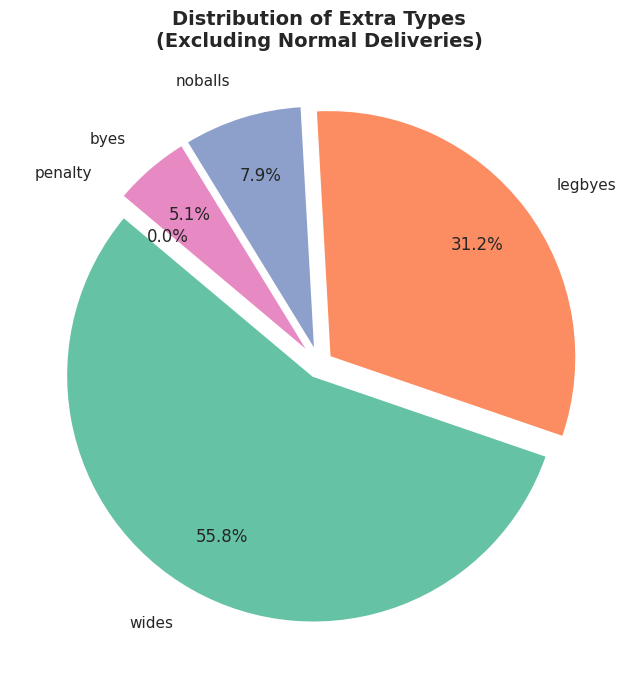


Extra Type Counts:
Extra_Type
wides      3496
legbyes    1950
noballs     493
byes        320
penalty       1


In [19]:
extra_counts = df[df['Extra_Type'] != 'Normal']['Extra_Type'].value_counts()

plt.figure(figsize=(7, 7))
plt.pie(extra_counts, labels=extra_counts.index, autopct='%1.1f%%',
        startangle=140, colors=sns.color_palette('Set2'),
        explode=[0.05] * len(extra_counts),
        pctdistance=0.75, labeldistance=1.15,
        wedgeprops={'edgecolor': 'white', 'linewidth': 2})
plt.title('Distribution of Extra Types\n(Excluding Normal Deliveries)',
          fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nExtra Type Counts:")
print(extra_counts.to_string())

# Q16. What is the most common way to get dismissed?


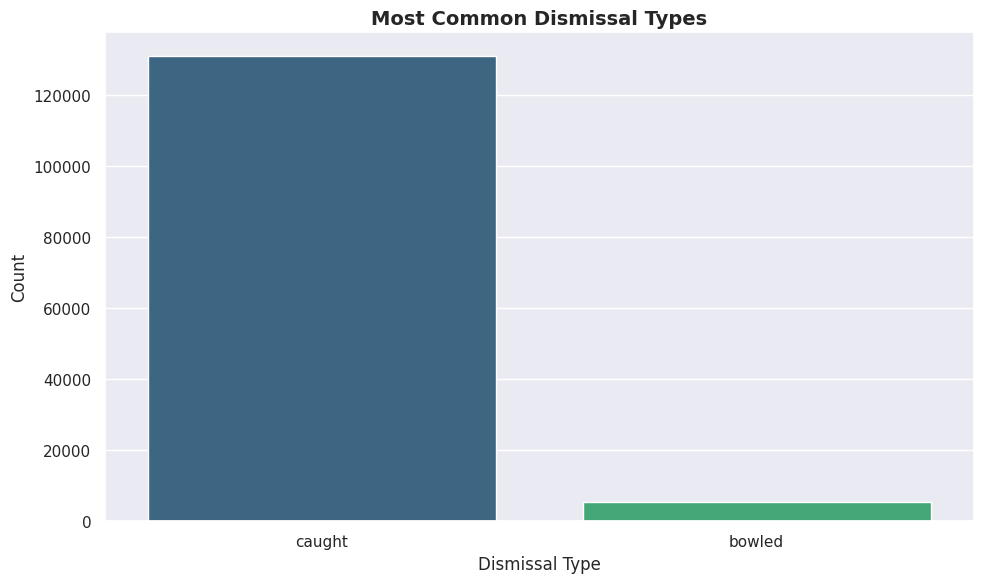

Dismissal_Type  Count
        caught 131058
        bowled   5532


In [21]:
dismissal_counts = df['Dissimal_Type'].value_counts().dropna().reset_index()
dismissal_counts.columns = ['Dismissal_Type' , 'Count']

plt.figure(figsize = (10,6))
sns.barplot(data = dismissal_counts , x ='Dismissal_Type' , y = 'Count',
            hue = 'Dismissal_Type' , palette = 'viridis' , legend = False)

plt.title('Most Common Dismissal Types', fontsize=14, fontweight='bold')
plt.xlabel('Dismissal Type')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

print(dismissal_counts.to_string(index=False))


# Q17. Which over sees the most wickets fall?


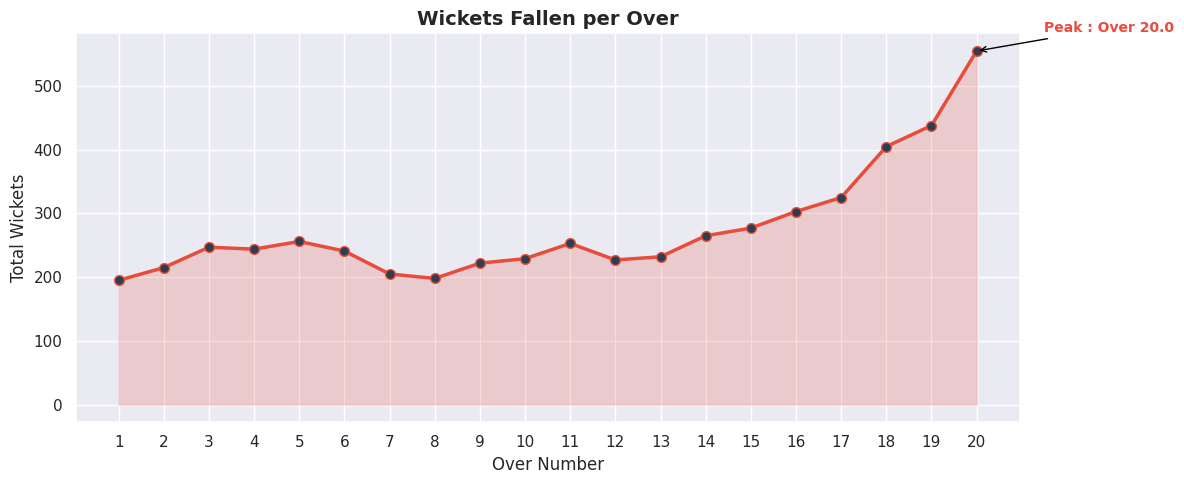

Most dangerous over for batsmen : Over 20.0 (555 wickets)


In [22]:
# Q17. Which over sees the most wickets fall?

over_wk = df[df['Player_dissmial_id'] != 0].groupby('Over_Id')['Player_dissmial_id'].count()

plt.figure(figsize=(12, 5))
plt.plot(over_wk.index, over_wk.values, marker='o', color='#e74c3c',
         linewidth=2.5, markersize=7, markerfacecolor='#2c3e50')
plt.fill_between(over_wk.index, over_wk.values, alpha=0.2, color='#e74c3c')
plt.title('Wickets Fallen per Over', fontsize=14, fontweight='bold')
plt.xlabel('Over Number')
plt.ylabel('Total Wickets')
plt.xticks(range(1, 21))

peak = over_wk.idxmax()
plt.annotate(f'Peak : Over {peak}',
             xy=(peak, over_wk[peak]),
             xytext=(peak + 1.5, over_wk[peak] + 30),
             arrowprops=dict(arrowstyle='->', color='black'),
             fontweight='bold', color='#e74c3c', fontsize=10)
plt.tight_layout()
plt.show()

print(f"Most dangerous over for batsmen : Over {peak} ({over_wk[peak]} wickets)")

# Q18. Does batting first or second win more matches?


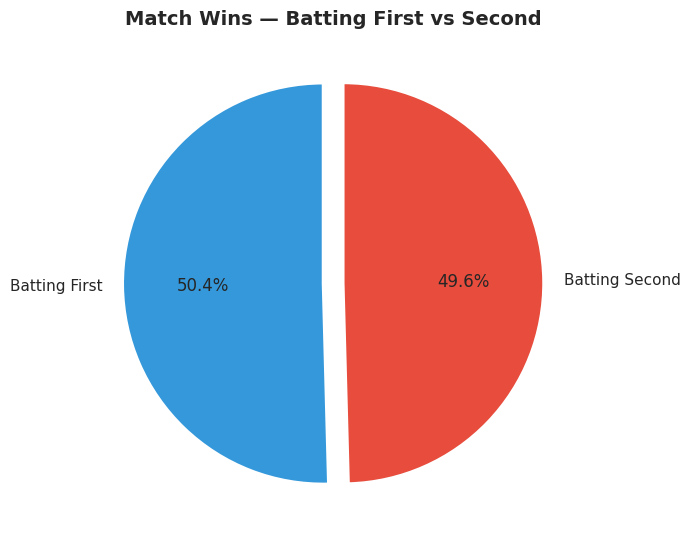

Batting First  Wins : 359
Batting Second Wins : 353


In [23]:
# Q18. Does batting first or second win more matches?

inn1 = df[df['Innings_Id'] == 1][['Match_Id', 'Team_Batting_Id', 'Match_Winner_Id']].drop_duplicates()
inn1['Won'] = (inn1['Team_Batting_Id'] == inn1['Match_Winner_Id']).astype(int)

inn2 = df[df['Innings_Id'] == 2][['Match_Id', 'Team_Batting_Id', 'Match_Winner_Id']].drop_duplicates()
inn2['Won'] = (inn2['Team_Batting_Id'] == inn2['Match_Winner_Id']).astype(int)

labels = ['Batting First', 'Batting Second']
wins   = [inn1['Won'].sum(), inn2['Won'].sum()]

plt.figure(figsize=(7, 7))
plt.pie(wins, labels=labels, autopct='%1.1f%%',
        colors=['#3498db', '#e74c3c'],
        explode=[0.05, 0.05],
        wedgeprops={'edgecolor': 'white', 'linewidth': 2},
        startangle=90)
plt.title('Match Wins — Batting First vs Second', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Batting First  Wins : {wins[0]}")
print(f"Batting Second Wins : {wins[1]}")

# Q19. How do teams perform in 1st vs 2nd innings?


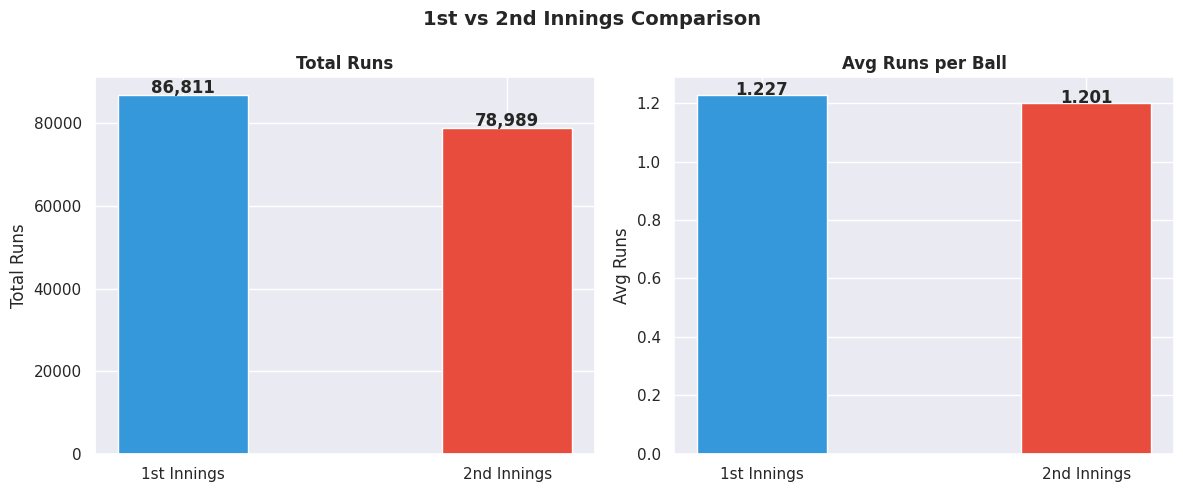

In [24]:
innings_stats = df[df['Innings_Id'].isin([1, 2])].groupby('Innings_Id').agg(
    Total_Runs = ('Batsman_Scored', 'sum'),
    Avg_Runs   = ('Batsman_Scored', 'mean'),
    Total_Balls = ('Ball_Id',       'count')
).reset_index()

innings_stats['Innings_Id'] = innings_stats['Innings_Id'].map({1:'1st Innings', 2:'2nd Innings'})

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('1st vs 2nd Innings Comparison', fontsize=14, fontweight='bold')

# Total Runs
bars1 = axes[0].bar(innings_stats['Innings_Id'], innings_stats['Total_Runs'],
                    color=['#3498db', '#e74c3c'], edgecolor='white', width=0.4)
axes[0].set_title('Total Runs', fontweight='bold')
axes[0].set_ylabel('Total Runs')
for bar in bars1:
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 500,
                 f'{int(bar.get_height()):,}', ha='center', fontweight='bold')

# Avg Runs per Ball
bars2 = axes[1].bar(innings_stats['Innings_Id'], innings_stats['Avg_Runs'],
                    color=['#3498db', '#e74c3c'], edgecolor='white', width=0.4)
axes[1].set_title('Avg Runs per Ball', fontweight='bold')
axes[1].set_ylabel('Avg Runs')
for bar in bars2:
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
                 f'{bar.get_height():.3f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

# Q21. What is the highest partnership in IPL?


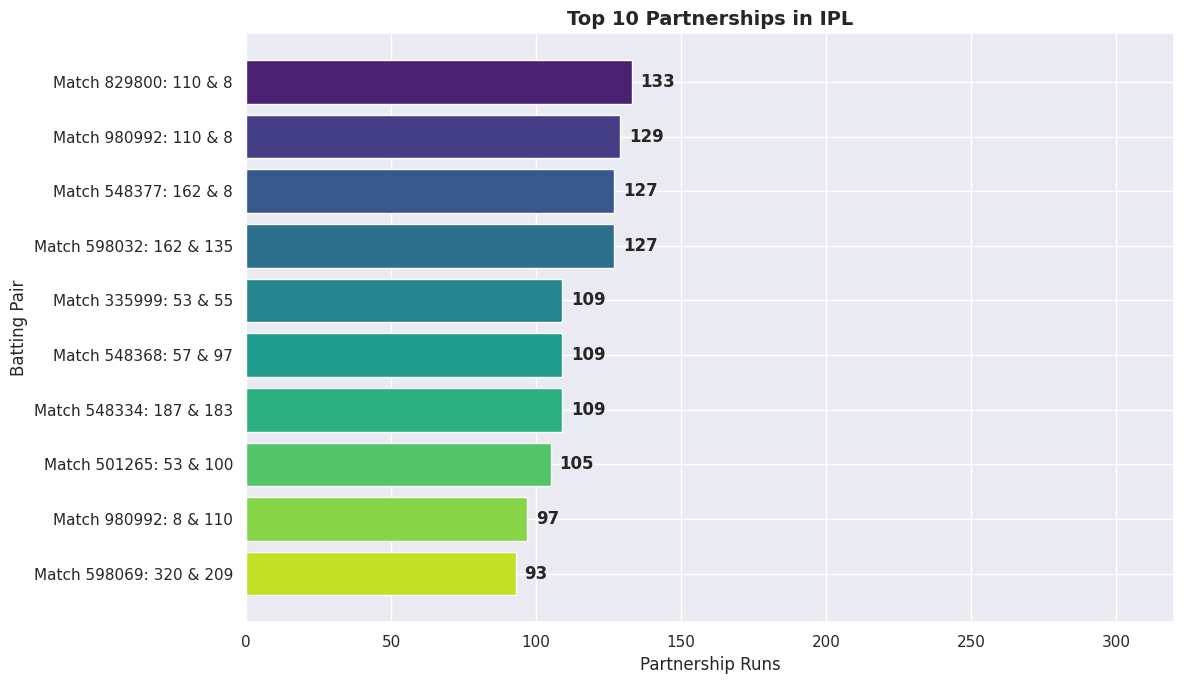

 Match_Id  Batsman1  Batsman2  Partnership_Runs
 829800.0     110.0       8.0               133
 980992.0     110.0       8.0               129
 548377.0     162.0       8.0               127
 598032.0     162.0     135.0               127
 335999.0      53.0      55.0               109
 548368.0      57.0      97.0               109
 548334.0     187.0     183.0               109
 501265.0      53.0     100.0               105
 980992.0       8.0     110.0                97
 598069.0     320.0     209.0                93


In [27]:


# Fix — group by match + over to get per-spell partnerships
partnership = df.groupby(['Match_Id', 'Innings_Id', 'Striker_Id', 'Non_Striker_Id'])['Batsman_Scored'].sum().reset_index()
partnership.columns = ['Match_Id', 'Innings_Id', 'Batsman1', 'Batsman2', 'Partnership_Runs']

# Keep only single match partnerships (realistic range)
partnership = partnership[partnership['Partnership_Runs'] <= 250]
top_partnerships = partnership.sort_values('Partnership_Runs', ascending=False).head(10)

plt.figure(figsize=(12, 7))
labels = [f'Match {int(r.Match_Id)}: {int(r.Batsman1)} & {int(r.Batsman2)}'
          for _, r in top_partnerships.iterrows()]

bars = plt.barh(labels, top_partnerships['Partnership_Runs'],
                color=sns.color_palette('viridis', 10), edgecolor='white')

plt.title('Top 10 Partnerships in IPL', fontsize=14, fontweight='bold')
plt.xlabel('Partnership Runs')
plt.ylabel('Batting Pair')
plt.xlim(0, 320)
plt.gca().invert_yaxis()

for bar in bars:
    plt.text(bar.get_width() + 3, bar.get_y() + bar.get_height()/2,
             f'{int(bar.get_width())}', va='center', fontweight='bold')

plt.tight_layout()
plt.show()

print(top_partnerships[['Match_Id','Batsman1','Batsman2','Partnership_Runs']].to_string(index=False))

📌 Q24. What does the perfect IPL batsman look like?


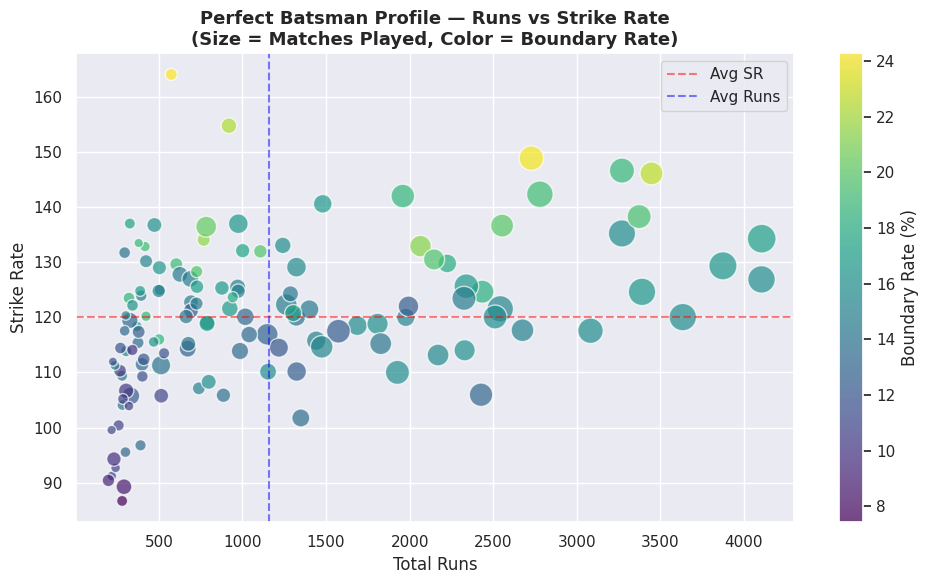

Perfect Batsman Stats (Top 5 by Strike Rate, min 200 balls):
 Striker_Id  Total_Runs  Strike_Rate  Avg_per_Match  Boundary_Rate
      334.0         574       164.00          22.96          24.29
      305.0         919       154.71          21.88          22.22
       41.0        2728       148.83          26.23          24.00
      110.0        3270       146.57          30.00          18.69
      162.0        3447       146.06          37.88          22.58


In [28]:


batsman_profile = df.groupby('Striker_Id').agg(
    Total_Runs   = ('Batsman_Scored', 'sum'),
    Balls_Faced  = ('Ball_Id',        'count'),
    Matches      = ('Match_Id',       'nunique'),
    Fours        = ('Batsman_Scored', lambda x: (x == 4).sum()),
    Sixes        = ('Batsman_Scored', lambda x: (x == 6).sum()),
    Dot_Balls    = ('Batsman_Scored', lambda x: (x == 0).sum())
).reset_index()

batsman_profile['Strike_Rate']  = (batsman_profile['Total_Runs'] / batsman_profile['Balls_Faced'] * 100).round(2)
batsman_profile['Avg_per_Match'] = (batsman_profile['Total_Runs'] / batsman_profile['Matches']).round(2)
batsman_profile['Boundary_Rate'] = ((batsman_profile['Fours'] + batsman_profile['Sixes']) / batsman_profile['Balls_Faced'] * 100).round(2)

# Filter meaningful sample
profile = batsman_profile[batsman_profile['Balls_Faced'] >= 200]

# Scatter — Runs vs Strike Rate
plt.figure(figsize=(10, 6))
scatter = plt.scatter(profile['Total_Runs'], profile['Strike_Rate'],
                      c=profile['Boundary_Rate'], cmap='viridis',
                      s=profile['Matches'] * 3, alpha=0.7, edgecolors='white')
plt.colorbar(scatter, label='Boundary Rate (%)')
plt.title('Perfect Batsman Profile — Runs vs Strike Rate\n(Size = Matches Played, Color = Boundary Rate)',
          fontsize=13, fontweight='bold')
plt.xlabel('Total Runs')
plt.ylabel('Strike Rate')

# Ideal zone
plt.axhline(y=profile['Strike_Rate'].mean(), color='red', linestyle='--', alpha=0.5, label='Avg SR')
plt.axvline(x=profile['Total_Runs'].mean(), color='blue', linestyle='--', alpha=0.5, label='Avg Runs')
plt.legend()
plt.tight_layout()
plt.show()

print("Perfect Batsman Stats (Top 5 by Strike Rate, min 200 balls):")
print(profile.sort_values('Strike_Rate', ascending=False)
      [['Striker_Id','Total_Runs','Strike_Rate','Avg_per_Match','Boundary_Rate']].head(5).to_string(index=False))

 Q25  Which Bowler-Batsman matchup is the most dominant?

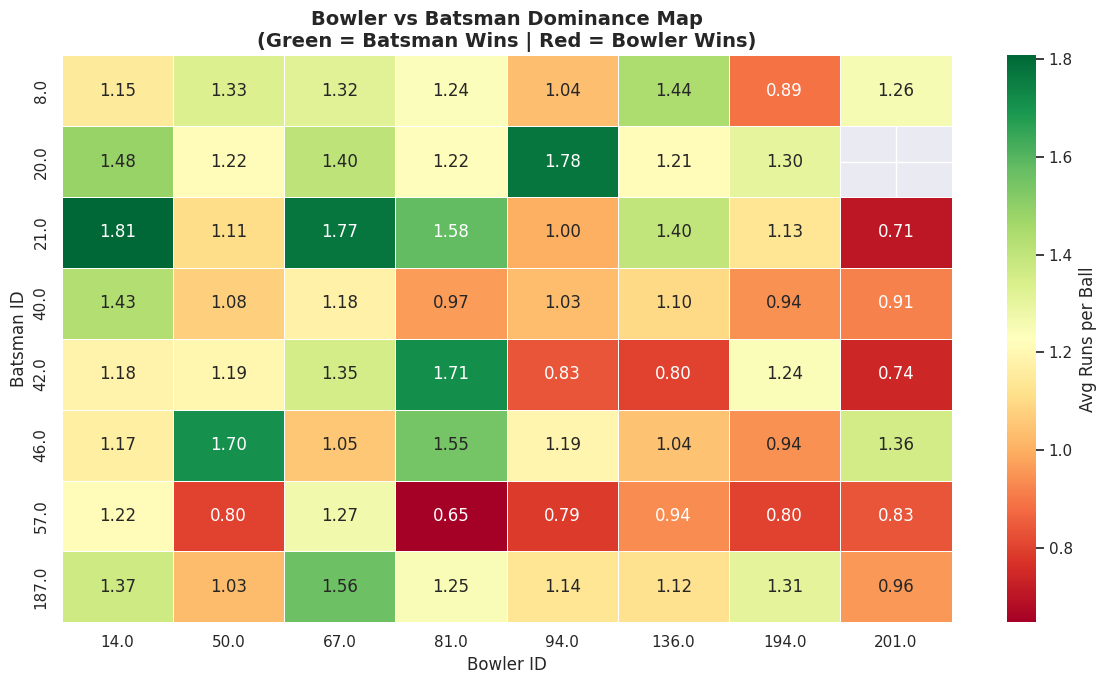

Most Dominant Batsman-Bowler Matchup:
Best Batsman : 21.0 vs Bowler 14.0 → 1.81 avg runs/ball
Best Bowler  : Bowler 81.0 vs Batsman 57.0 → 0.65 avg runs/ball


In [30]:
# Get top 10 batsmen and top 10 bowlers by frequency
top_bat  = df['Striker_Id'].value_counts().head(8).index
top_bowl = df['Bowler_Id'].value_counts().head(8).index

# Filter only matchups between them
matchup = df[df['Striker_Id'].isin(top_bat) & df['Bowler_Id'].isin(top_bowl)]

# Pivot — avg runs scored by batsman against bowler
pivot = matchup.groupby(['Striker_Id','Bowler_Id'])['Batsman_Scored'].mean().unstack()

plt.figure(figsize=(12, 7))
sns.heatmap(pivot,
            annot=True, fmt='.2f',
            cmap='RdYlGn',
            linewidths=0.5,
            linecolor='white',
            cbar_kws={'label':'Avg Runs per Ball'})

plt.title('Bowler vs Batsman Dominance Map\n(Green = Batsman Wins | Red = Bowler Wins)',
          fontsize=14, fontweight='bold')
plt.xlabel('Bowler ID', fontsize=12)
plt.ylabel('Batsman ID', fontsize=12)
plt.tight_layout()
plt.show()

# Insight
best_matchup = matchup.groupby(['Striker_Id','Bowler_Id'])['Batsman_Scored'].mean()
print("Most Dominant Batsman-Bowler Matchup:")
print(f"Best Batsman : {best_matchup.idxmax()[0]} vs Bowler {best_matchup.idxmax()[1]} → {best_matchup.max():.2f} avg runs/ball")
print(f"Best Bowler  : Bowler {best_matchup.idxmin()[1]} vs Batsman {best_matchup.idxmin()[0]} → {best_matchup.min():.2f} avg runs/ball")

